In [1]:
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
DATA_DIR = Path("../data/raw/plantvillage dataset/color")
print(f"Pfad existiert: {DATA_DIR.exists()}")
print(f"Absoluter Pfad: {DATA_DIR.resolve()}")

Pfad existiert: True
Absoluter Pfad: C:\dev\plant-doctor\data\raw\plantvillage dataset\color


In [3]:
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Anzahl Klassen: {len(classes)}")
print("\nErste 10:")
for c in classes[:10]:
    print(f"  - {c}")

Anzahl Klassen: 38

Erste 10:
  - Apple___Apple_scab
  - Apple___Black_rot
  - Apple___Cedar_apple_rust
  - Apple___healthy
  - Blueberry___healthy
  - Cherry_(including_sour)___Powdery_mildew
  - Cherry_(including_sour)___healthy
  - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  - Corn_(maize)___Common_rust_
  - Corn_(maize)___Northern_Leaf_Blight


In [4]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

class_counts = {}
for class_dir in DATA_DIR.iterdir():
    if class_dir.is_dir():
        n = sum(1 for f in class_dir.iterdir() if f.suffix in IMAGE_EXTS)
        class_counts[class_dir.name] = n

df = pd.DataFrame({
    'class': list(class_counts.keys()),
    'count': list(class_counts.values())
}).sort_values('count', ascending=False)

print(f"Gesamtanzahl Bilder: {df['count'].sum()}")
print(f"Min: {df['count'].min()}  |  Max: {df['count'].max()}  |  Mean: {df['count'].mean():.0f}")
df.head(10)

Gesamtanzahl Bilder: 54305
Min: 152  |  Max: 5507  |  Mean: 1429


,class,count
15,Orange___Haunglongbing_(Citrus_greening),5507
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
24,Soybean___healthy,5090
16,Peach___Bacterial_spot,2297
28,Tomato___Bacterial_spot,2127
31,Tomato___Late_blight,1909
25,Squash___Powdery_mildew,1835
33,Tomato___Septoria_leaf_spot,1771
34,Tomato___Spider_mites Two-spotted_spider_mite,1676
3,Apple___healthy,1645


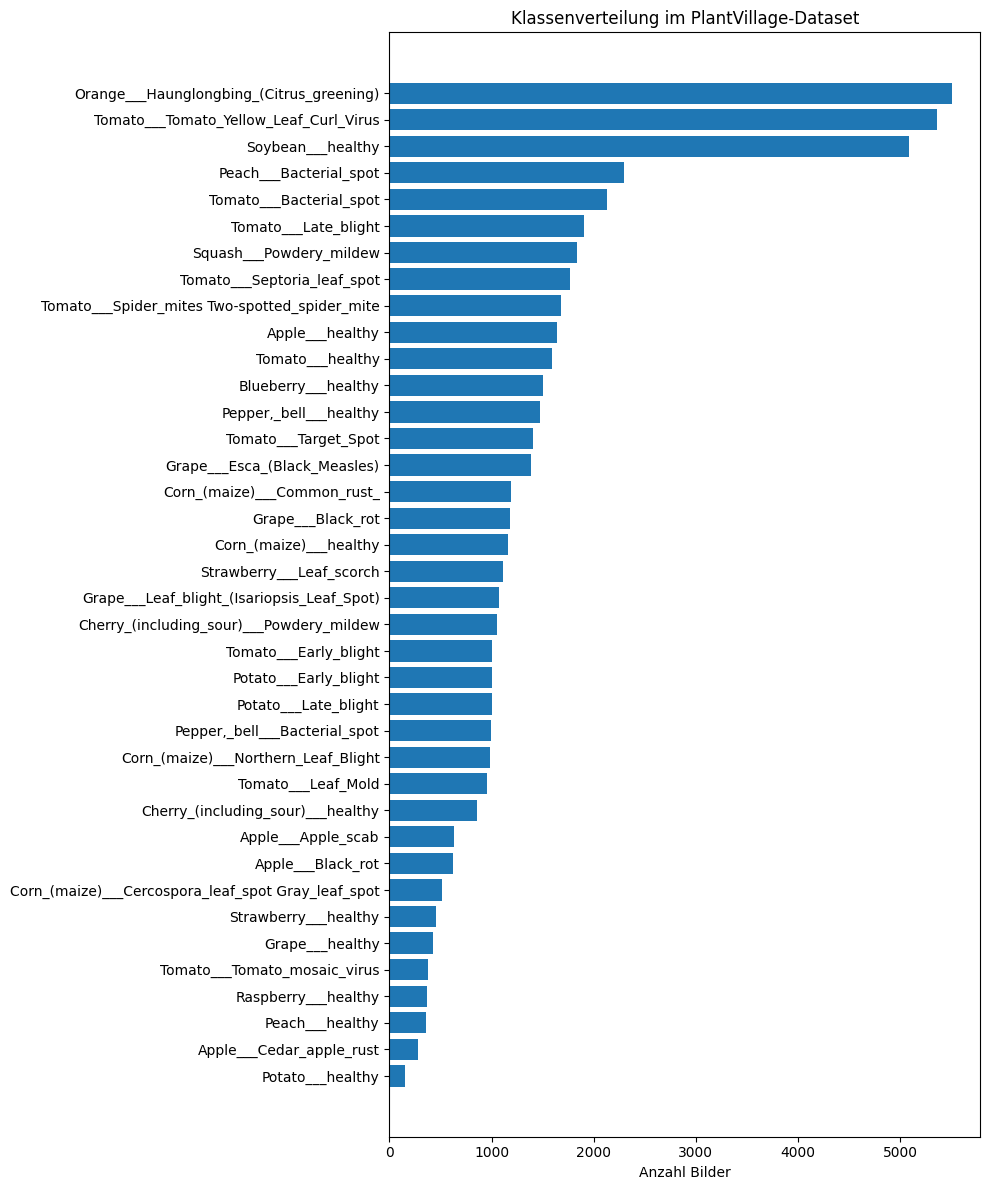

In [5]:
fig, ax = plt.subplots(figsize=(10, 12))
df_sorted = df.sort_values('count')
ax.barh(df_sorted['class'], df_sorted['count'])
ax.set_xlabel('Anzahl Bilder')
ax.set_title('Klassenverteilung im PlantVillage-Dataset')
plt.tight_layout()
plt.show()

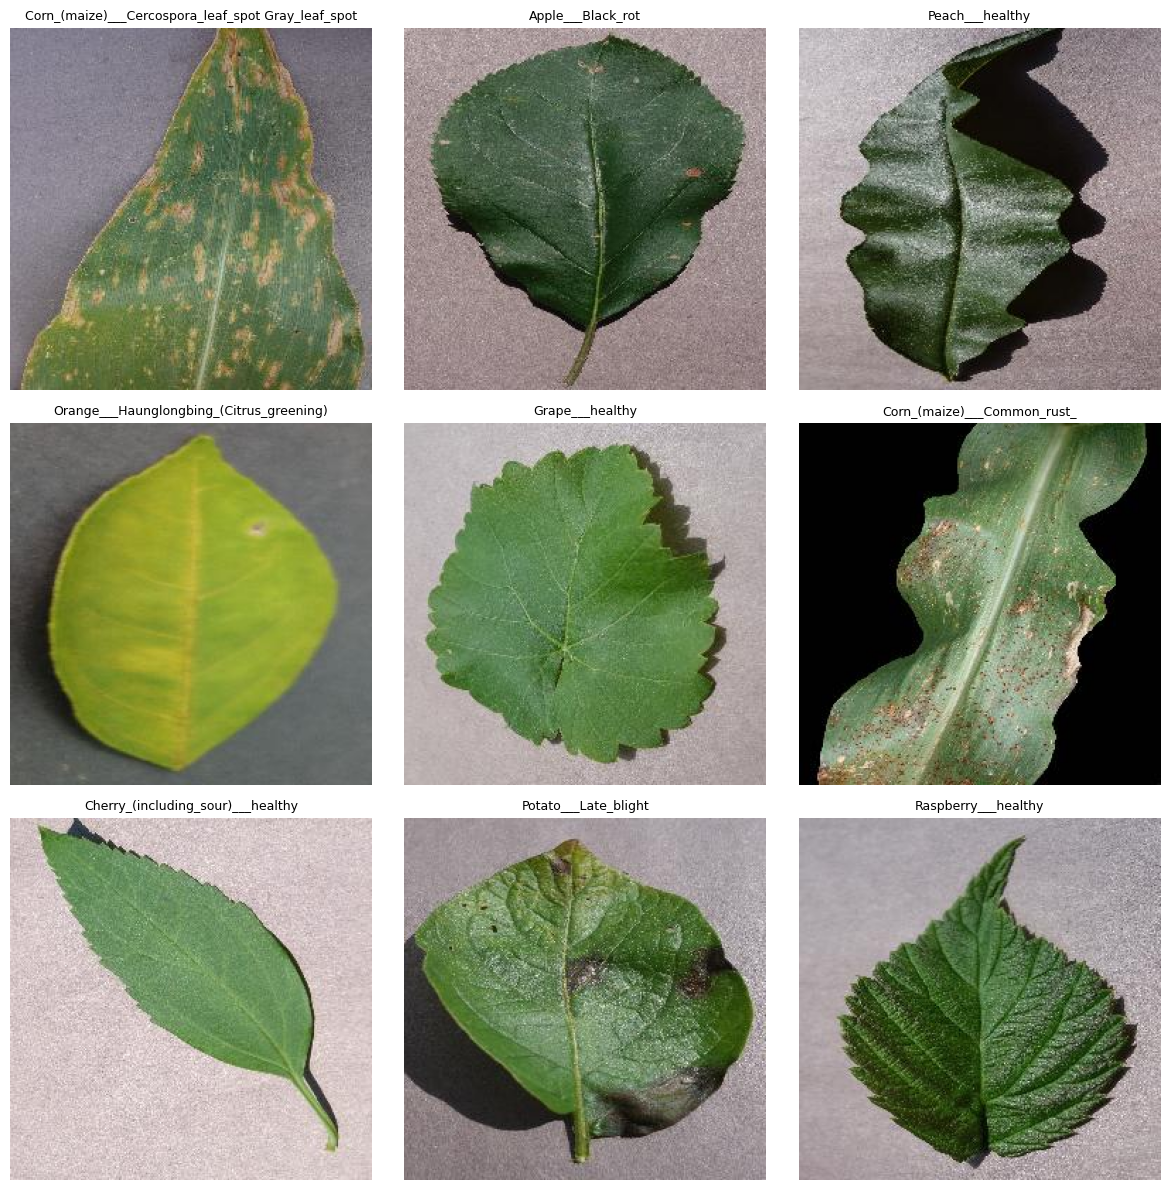

In [7]:
random.seed(42)
sample_classes = random.sample(classes, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, class_name in zip(axes.flat, sample_classes):
    class_dir = DATA_DIR / class_name
    images = [f for f in class_dir.iterdir() if f.suffix in IMAGE_EXTS]
    if images:
        img = Image.open(random.choice(images))
        ax.imshow(img)
        ax.set_title(class_name, fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
random.seed(42)
sample_dimensions = []
for class_name in random.sample(classes, 5):
    class_dir = DATA_DIR / class_name
    images = [f for f in class_dir.iterdir() if f.suffix in IMAGE_EXTS][:20]
    for img_path in images:
        with Image.open(img_path) as img:
            sample_dimensions.append(img.size)

unique_dims = set(sample_dimensions)
print(f"Unique dimensions in sample of {len(sample_dimensions)} images:")
for dim in unique_dims:
    print(f"  {dim}")

Unique dimensions in sample of 100 images:
  (256, 256)


## Erkenntnisse aus der EDA

- 38 Klassen, ~54.000 Bilder total
- 14 Pflanzenarten mit jeweils mehreren Krankheits-Klassen + healthy-Klasse
- **Stark imbalanciert**: kleinste Klasse ~150 Bilder, größte ~5000
- Alle Bilder einheitlich 256×256 Pixel
- **Domain-Gap**: einzelne Blätter auf neutralem Hintergrund, nicht "in the wild"
- Konsequenzen fürs Modell:
  - Class-weighted Loss oder Oversampling für minor classes
  - Augmentation simulieren reale Foto-Bedingungen (Rotation, Lighting, etc.)
  - Eventuell Test mit selbst aufgenommenen iPhone-Fotos planen